# Loan Default Prediction — Neural Network Classifier

**Dataset:** LendingClub loan data  
**Goal:** Predict whether a borrower will fully repay or default (charge off) on a loan  
**Challenge:** Class imbalance — fully paid loans significantly outnumber defaults  

### Approach
- Full sklearn preprocessing pipeline (imputation + scaling + encoding)
- Class imbalance handled via weighted loss, not oversampling
- Neural network with early stopping and dropout regularization

---

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Data Import

In [4]:
DIR_PATH = os.path.dirname(os.path.abspath(__name__))
FILE_PATH = os.path.join(DIR_PATH, 'DATA/lending_club_loan_two.csv')

df = pd.read_csv(FILE_PATH)
print(f'Dataset shape: {df.shape}')

Dataset shape: (396030, 27)


## 3. Exploratory Data Analysis

First pass: understand the data structure, check for missing values, and decide which columns to keep or drop.

In [5]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396030.0,14113.888089,8357.441341,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396030.0,13.639400,4.472157,5.32,10.49,13.33,16.49,30.99
installment,396030.0,431.849698,250.727790,16.08,250.33,375.43,567.30,1533.81
annual_inc,396030.0,74203.175798,61637.621158,0.00,45000.00,64000.00,90000.00,8706582.00
dti,396030.0,17.379514,18.019092,0.00,11.28,16.91,22.98,9999.00
open_acc,396030.0,11.311153,5.137649,0.00,8.00,10.00,14.00,90.00
pub_rec,396030.0,0.178191,0.530671,0.00,0.00,0.00,0.00,86.00
revol_bal,396030.0,15844.539853,20591.836109,0.00,6025.00,11181.00,19620.00,1743266.00
revol_util,395754.0,53.791749,24.452193,0.00,35.80,54.80,72.90,892.30
total_acc,396030.0,25.414744,11.886991,2.00,17.00,24.00,32.00,151.00


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

### 3.1 Target Variable Distribution

Checking class balance before any preprocessing.

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64


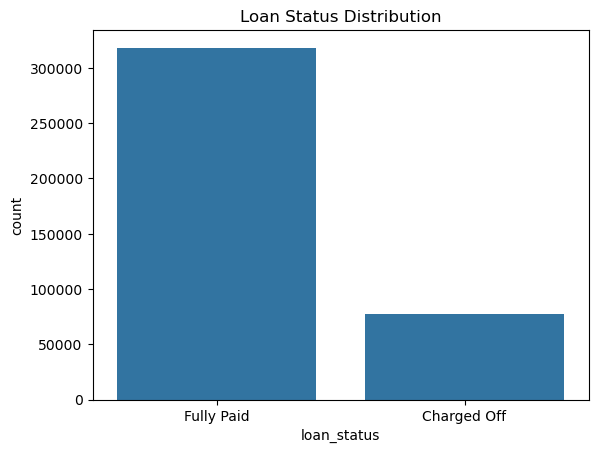

In [8]:
print(df['loan_status'].value_counts())
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()

### 3.2 Categorical Column Review

Checking cardinality of each categorical column to decide what to keep, encode, or drop.

| Column | Decision | Reason |
|---|---|---|
| term | keep | low cardinality, meaningful |
| grade | keep | ordinal risk indicator |
| sub_grade | drop | redundant with grade |
| emp_title | drop | too many unique values, noisy |
| emp_length | keep | meaningful employment signal |
| home_ownership | keep | financial stability indicator |
| verification_status | keep | data quality signal |
| issue_d | drop | data leakage risk |
| purpose | keep | meaningful loan context |
| title | drop | free text, redundant with purpose |
| earliest_cr_line | engineer | extract month and year, then drop |
| initial_list_status | keep | |
| application_type | keep | |
| address | drop | too granular, noisy |

In [9]:
categorical_cols = ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
                    'home_ownership', 'verification_status', 'purpose',
                    'initial_list_status', 'application_type']

for col in categorical_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- term ---
term
36 months    302005
60 months     94025
Name: count, dtype: int64

--- grade ---
grade
B    116018
C    105987
A     64187
D     63524
E     31488
F     11772
G      3054
Name: count, dtype: int64

--- sub_grade ---
sub_grade
B3    26655
B4    25601
C1    23662
C2    22580
B2    22495
B5    22085
C3    21221
C4    20280
B1    19182
A5    18526
C5    18244
D1    15993
A4    15789
D2    13951
D3    12223
D4    11657
A3    10576
A1     9729
D5     9700
A2     9567
E1     7917
E2     7431
E3     6207
E4     5361
E5     4572
F1     3536
F2     2766
F3     2286
F4     1787
F5     1397
G1     1058
G2      754
G3      552
G4      374
G5      316
Name: count, dtype: int64

--- emp_title ---
emp_title
Teacher                    4389
Manager                    4250
Registered Nurse           1856
RN                         1846
Supervisor                 1830
                           ... 
Postman                       1
McCarthy & Holthus, LLC       1
jp flooring             

### 3.3 Missing Values

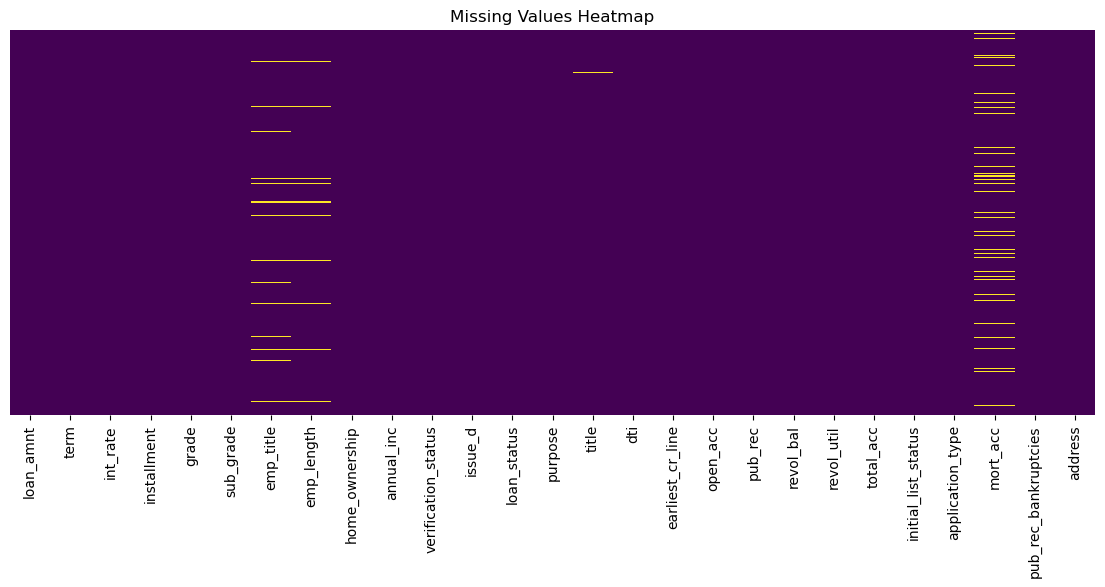


Missing value counts:
emp_title               22927
emp_length              18301
title                    1756
revol_util                276
mort_acc                37795
pub_rec_bankruptcies      535
dtype: int64


In [10]:
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

print('\nMissing value counts:')
print(df.isnull().sum()[df.isnull().sum() > 0])

`mort_acc` has substantial missing values and is dropped. Remaining missing values in numerical columns will be imputed with the median in the preprocessing pipeline.

## 4. Feature Engineering & Cleaning

In [11]:
# Extract month and year from earliest_cr_line before dropping
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['month'] = df['earliest_cr_line'].apply(lambda x: x.month)
df['year'] = df['earliest_cr_line'].apply(lambda x: x.year)

# Drop columns decided in EDA
cols_to_drop = ['sub_grade', 'emp_title', 'issue_d', 'title',
                'address', 'earliest_cr_line', 'mort_acc']
df.drop(cols_to_drop, axis=1, inplace=True)

print(f'Remaining columns ({len(df.columns)}):')
print(df.columns.tolist())

C:\Users\PC\AppData\Local\Temp\ipykernel_10544\3811351185.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


Remaining columns (22):
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'pub_rec_bankruptcies', 'month', 'year']


## 5. Preprocessing Pipeline

Using `sklearn` pipelines with `ColumnTransformer` to apply separate transformations to numerical and categorical columns cleanly and without data leakage.

In [12]:
y = df['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})
X = df.drop('loan_status', axis=1)

print('Class distribution:')
print(y.value_counts())
print(f'\nImbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}x')

Class distribution:
loan_status
1    318357
0     77673
Name: count, dtype: int64

Imbalance ratio: 0.24x


In [13]:
numerical_columns = ['loan_amnt', 'int_rate', 'installment',
                     'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
                     'total_acc', 'pub_rec_bankruptcies', 'month', 'year']

categorical_columns = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
                       'purpose', 'initial_list_status', 'application_type']

# Numerical: impute with median, then scale to [0,1]
# add_indicator=True creates binary flag columns for rows where imputation occurred
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', MinMaxScaler())
])

# Categorical: impute with most frequent, then one-hot encode
# handle_unknown='ignore' sets unseen categories to zero vector at inference
# sparse_output=False required for Keras dense layers
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

## 6. Train/Test Split & Class Weights

`stratify=y` ensures the class ratio is preserved in both train and test sets.

`compute_class_weight` penalizes the model more for misclassifying the minority class (defaults), preventing it from achieving high accuracy simply by predicting the majority class.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {0: float(weights[0]), 1: float(weights[1])}

print(f'Class weights: {class_weight}')
print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

print(f'\nFeature matrix shape after preprocessing: {X_train.shape}')

Class weights: {0: 2.549357880845859, 1: 0.6219894301217971}
Train size: 316,824 | Test size: 79,206

Feature matrix shape after preprocessing: (316824, 63)


## 7. Model Architecture

Standard architecture for tabular binary classification: `64 → 32 → 1`  
Dropout (0.2) after first layer to reduce overfitting.  
Sigmoid output for binary probability.

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=25,
    restore_best_weights=True
)

model = Sequential([
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Training

`validation_split=0.2` holds back part of training data for validation — the test set remains completely unseen until final evaluation.  
`batch_size=32` is important for stable gradient updates on this dataset size.

In [16]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=300,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.6370 - val_loss: 0.6594
Epoch 2/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6331 - val_loss: 0.6215
Epoch 3/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.6320 - val_loss: 0.6372
Epoch 4/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6307 - val_loss: 0.6410
Epoch 5/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6294 - val_loss: 0.6231
Epoch 6/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.6286 - val_loss: 0.6346
Epoch 7/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6277 - val_loss: 0.6274
Epoch 8/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.6268 - val_loss: 0.6248
Epoch 9/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6262 - val_loss: 0.6274
Epoch 10/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.6260 - val_loss: 0.6293
Epoch 11/300
7921/7921 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.6254 - val_loss: 0.6117
Epoch 12

## 9. Evaluation

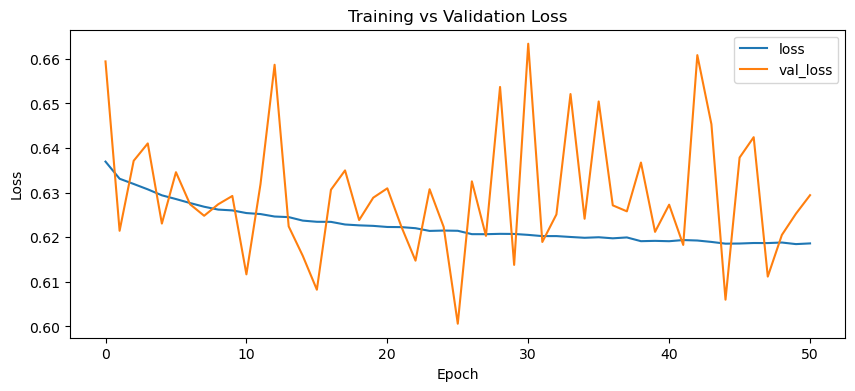

In [17]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot(figsize=(10, 4))
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

2476/2476 ━━━━━━━━━━━━━━━━━━━━ 2s 854us/step
Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.63      0.42     15535
           1       0.88      0.67      0.76     63671

    accuracy                           0.67     79206
   macro avg       0.60      0.65      0.59     79206
weighted avg       0.77      0.67      0.70     79206


Confusion Matrix:


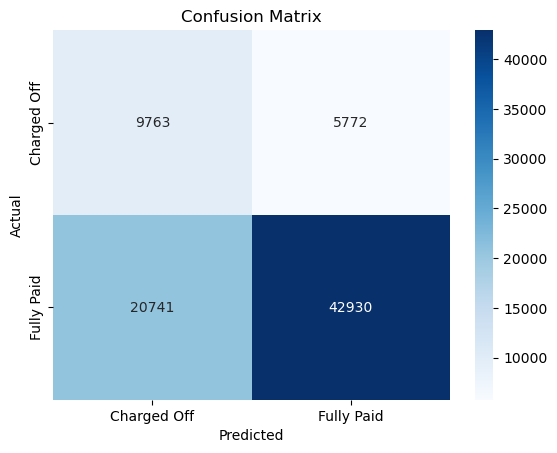

In [18]:
predictions = model.predict(X_test)
y_pred = (predictions >= 0.5).astype(int)

print('Classification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Charged Off', 'Fully Paid'],
            yticklabels=['Charged Off', 'Fully Paid'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 10. Key Takeaways

- Class imbalance is a real problem in credit risk datasets — accuracy alone is a misleading metric; recall on the minority class matters more
- `compute_class_weight` is a cleaner solution than oversampling for neural networks
- sklearn pipelines prevent data leakage and make the preprocessing reproducible at inference
- Early stopping with `restore_best_weights=True` removes the need for manual epoch tuning
